In [ ]:
# Setup and Loading

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from pandas.plotting import scatter_matrix

# Load the data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [ ]:
# EDA

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex  

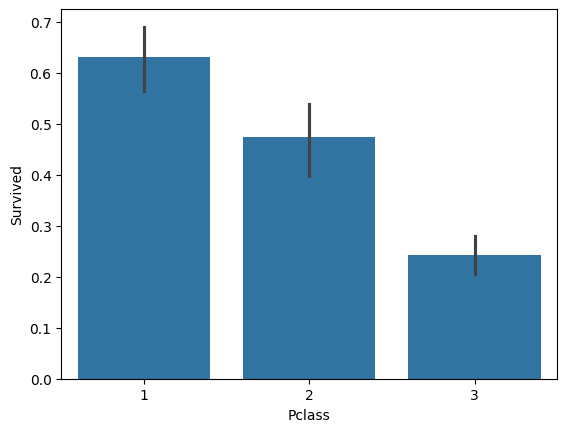

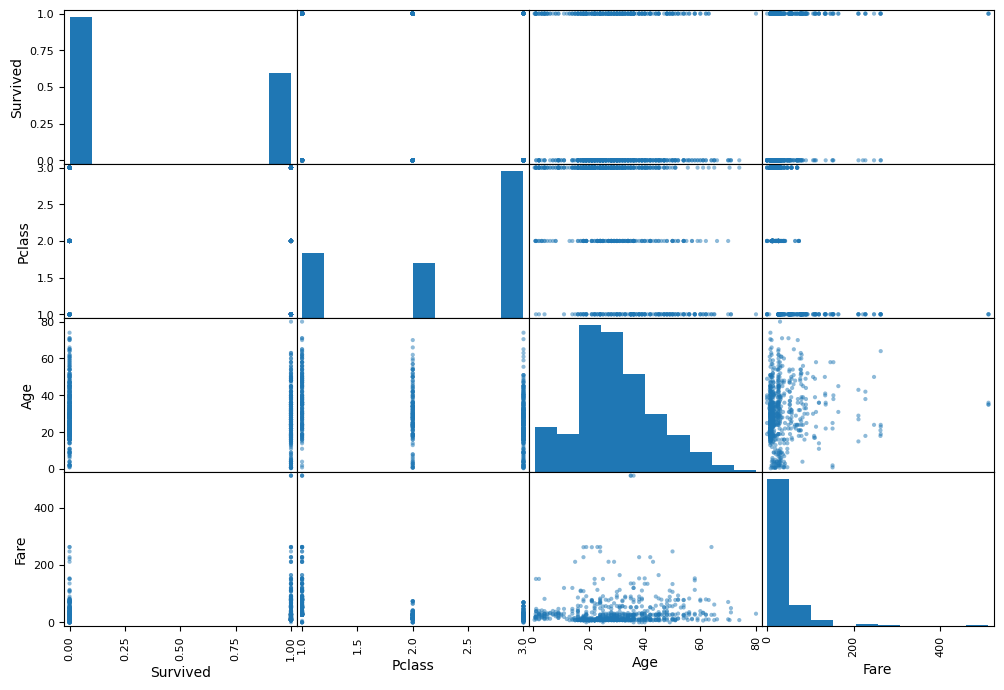

In [ ]:
# Analysis 1: Summary statistics
print(train.describe())

# Analysis 2: Check for missing values
print(train.isnull().sum())

# Analysis 3: Visualizing Survival by Class
sns.barplot(x='Pclass', y='Survived', data=train)
plt.show()

attributes = ["Survived", "Pclass", "Age", "Fare"]
scatter_matrix(train[attributes], figsize=(12, 8))
plt.show()



In [ ]:
#ETL

In [ ]:
def clean_data(df):
    # Fill missing Age with the median
    df['Age'] = df['Age'].fillna(df['Age'].median())
    # Fill missing Fare in test set
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    # Convert Sex to binary (0 or 1)
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    # Select only numerical features for the model
    return df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]

X_train = clean_data(train)
y_train = train['Survived']
X_test = clean_data(test)

In [ ]:
# Model Training

In [ ]:
# Initialize and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Calculate Accuracy
accuracy = model.score(X_train, y_train)
print(f"Training Accuracy: {accuracy * 100:.2f}%")

Training Accuracy: 79.57%


In [ ]:
#Final Prediction

In [ ]:
predictions = model.predict(X_test)

output = pd.DataFrame({'PassengerId': test.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("Submission file saved!")

Submission file saved!
